In [1]:
import os
from flonacomldft.utils.io_utils import load_pickle_file

import numpy as np
import matplotlib.pyplot as plt
from ase.io import read

import matplotlib.pylab as pylab

size=16
params = {'legend.fontsize': size,
          'figure.figsize': (15, 5),
         'axes.labelsize': size,
         'axes.titlesize': size,
         'xtick.labelsize': size,
         'ytick.labelsize': size}

pylab.rcParams.update(params)

/mnt/home/amolina/miniconda3/envs/ml-dft/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [55]:
# /mnt/home/amolina/ceph/adaptive-350/adaptive-dft/7-free-energy/results_free_energy_20231031182940

In [59]:
PATH_PROJECT = '/mnt/home/amolina/ceph/adaptive-350/adaptive-dft'

DFT_FE_SIMS = ['/7-free-energy/results_free_energy_0/results_BARs.pkl', 
               '/7-free-energy/results_free_energy_0/results_TFPs.pkl']

MLP_FE_SIMS = ['/7-free-energy/results_free_energy_20231031182940/results_BARs.pkl', 
               '/7-free-energy/results_free_energy_20231031182940/results_TFPs.pkl',
               '/7-free-energy/results_free_energy_20231031182940/results_BARs_md.pkl', ]

In [62]:
keys = ['BAR', 'TFP', 'BAR_MD']

dic_results_dft = {key: load_pickle_file(DFT_FE_SIMS[i], PATH_PROJECT) for i, key in enumerate(keys[:-1])}
dic_results_mlp = {key: load_pickle_file(MLP_FE_SIMS[i], PATH_PROJECT) for i, key in enumerate(keys)}

In [63]:
dic_results = {'DFT': dic_results_dft, 'MLP': dic_results_mlp}

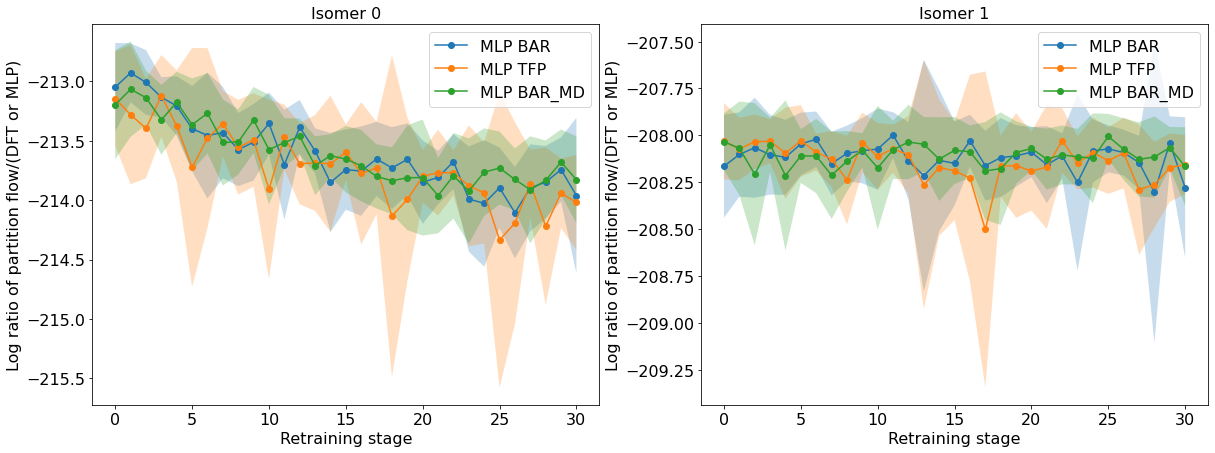

In [65]:
isomer_labels = np.array([0, 1])

fig, axs = plt.subplots(1, 2, figsize=(20, 7))

for isomer, ax in zip(isomer_labels, axs):

    ax.set_title('Isomer '+str(isomer))

    for key_results in ['MLP']:#dic_results.keys():


        for key in keys:

            means = np.array(dic_results[key_results][key][isomer]['means'])
            stds = np.array(dic_results[key_results][key][isomer]['stds'])

            if key_results == 'DFT':
                r = 10
            else:
                r = 1

            ax.plot(np.arange(len(means))*r, means, 'o-', label= key_results +' '+ key)
            ax.fill_between(np.arange(len(means))*r, means - stds, means + stds, alpha=0.25)

            ax.legend()

            ax.set_xlabel('Retraining stage')
            ax.set_ylabel('Log ratio of partition flow/(DFT or MLP)')

In [66]:
from ase.units import kB
T=350

In [67]:
np.array(dic_results_dft['BAR'][0]['means']),np.array(dic_results_dft['BAR'][1]['means'])

(array([-213.30332694, -212.75954788, -212.78320804, -213.21502386]),
 array([-206.74472284, -207.28382894, -206.91049665, -208.18312568]))

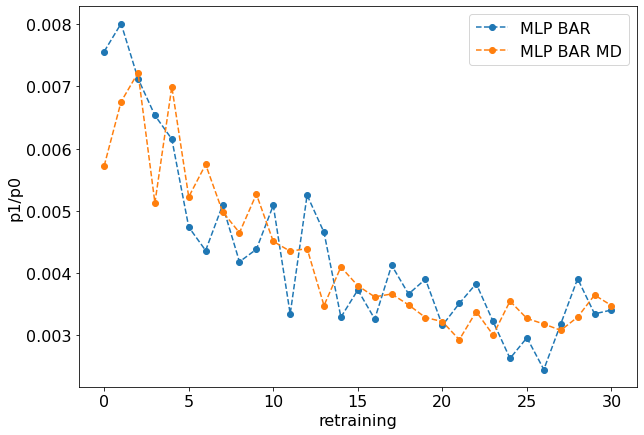

In [75]:
plt.figure(figsize=(10, 7))
#plt.plot(np.arange(0, 31, 10), np.exp(np.array(dic_results_dft['BAR'][0]['means'])-np.array(dic_results_dft['BAR'][1]['means'])), 'o--', label = 'DFT BAR' )
plt.plot( np.exp(np.array(dic_results_mlp['BAR'][0]['means'])-np.array(dic_results_mlp['BAR'][1]['means'])), 'o--', label = 'MLP BAR' )
plt.plot( np.exp(np.array(dic_results_mlp['BAR_MD'][0]['means'])-np.array(dic_results_mlp['BAR_MD'][1]['means'])), 'o--', label = 'MLP BAR MD'  )
plt.xlabel('retraining') 
plt.ylabel('p1/p0')
plt.legend()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


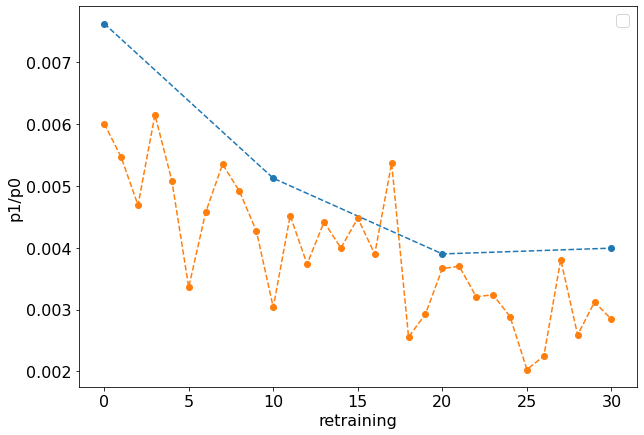

In [74]:
plt.figure(figsize=(10, 7))
plt.plot(np.arange(0, 31, 10), np.exp(np.array(dic_results_dft['TFP'][0]['means'])-np.array(dic_results_dft['TFP'][1]['means'])), 'o--')
plt.plot(np.exp(np.array(dic_results_mlp['TFP'][0]['means'])-np.array(dic_results_mlp['TFP'][1]['means'])), 'o--' )
plt.xlabel('retraining') 
plt.ylabel('p1/p0')
plt.legend()

In [6]:
from flonacomldft.internal_coordinates import Coordinates_mapping
coord_mapping = Coordinates_mapping()
import torch
import warnings
warnings.filterwarnings('ignore')

/mnt/home/amolina/miniconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/mnt/home/amolina/miniconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/mnt/home/amolina/miniconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/mnt/home/amolina/miniconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51

In [9]:
def read_sample_get_rc(path, isomer):

    list_file_md = [f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]
    list_file_md.remove('init_calc.out')
    molecules = [read(path + '/' + file) for file in list_file_md]
    #flow_md_zmat = coord_mapping.get_internal_from_trajectory(molecules, isomer=isomer, temperature=350)
    #flow_md_rc = coord_mapping.get_real_centered_from_internal(flow_md_zmat[:, :12], 
    #                                                              isomer=isomer, 
    #                                                              energies=flow_md_zmat[:, 12],
    #                                                              temperature=350)
    
    return molecules#torch.cat((flow_md_rc[0], flow_md_rc[2].reshape(-1, 1)), dim=1)

In [4]:
import torch

In [5]:
path = '/mnt/home/amolina/ceph/adaptive-350/adaptive-dft/5-multimodal/results_multimodal_sampling_mixture_29810981/DFTComputations_29810981'

In [6]:
mcmc0 = load_pickle_file('mnt/home/amolina/ceph/adaptive-350/adaptive-dft/5-multimodal/results_multimodal_sampling_mixture_29819950/mixture_mcmc_dic_29819950.pkl', '')
mcmc1 = load_pickle_file('mnt/home/amolina/ceph/adaptive-350/adaptive-dft/5-multimodal/results_multimodal_sampling_mixture_29819951/mixture_mcmc_dic_29819951.pkl', '')


In [7]:
energies = torch.cat([mcmc0['us'].flatten(), mcmc1['us'].flatten()])

In [52]:
xs = read_sample_get_rc(path, 0)

In [53]:
us = [x.get_potential_energy() for x in xs]

In [54]:
isomer=0
flow_md_zmat = coord_mapping.get_internal_from_trajectory(xs, isomer=isomer, temperature=350)
#flow_md_rc = coord_mapping.get_real_centered_from_internal(flow_md_zmat[:, :12], 
#                                                              isomer=isomer, 
#                                                              energies=flow_md_zmat[:, 12],
#                                                              temperature=350)

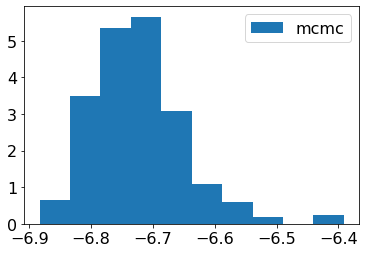

In [8]:
plt.hist(energies.flatten().detach(), density=True, bins=10, label='mcmc')
#plt.hist(np.array(us)-0.35, density=True, bins=10, alpha=0.5)
plt.legend()